# Examining the data

What is wrong with `survey.csv`, and what the cleaning does about it.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

from src.clean import (AGE_CEILING, MIN_WORKING_AGE, TARGET, Z_THRESHOLD,
                       clean, country_median_ratio, derive_salary_bounds, load_raw)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})
KEEP, DROP = "tab:blue", "tab:red"

RAW = load_raw()
FINAL = clean()
print(f'kept {len(FINAL)} of {len(RAW)} rows ({len(FINAL)/len(RAW)*100:.1f}%)')

kept 4795 of 5000 rows (95.9%)


## 1. The salary column

In [2]:
with_salary = RAW.dropna(subset=[TARGET])
sal = with_salary[TARGET]

print(f"range ${sal.min():,.0f} to ${sal.max():,.0f}   median ${sal.median():,.0f}")
print(f"lowest values: {sorted(sal)[:6]}")
print(f"1st percentile: ${np.percentile(sal, 1):,.0f}")

range $1 to $6,890,299   median $77,559
lowest values: [1.0, 1.0, 1.0, 2.0, 3.0, 3.0]
1st percentile: $86


Salaries run from $1 to $6.9M and the 1st percentile is $85. The bottom of that range is
not real, so a floor is needed.

The spread also explains why the model predicts `log(salary)` rather than salary: on a
linear scale a handful of million-dollar values dominate everything else.

## 2. Where to cut

Salaries are compared to the median for their own country, not to a dollar amount. A ratio
of 1.0 is typical for that country.

On that scale the junk separates itself out.

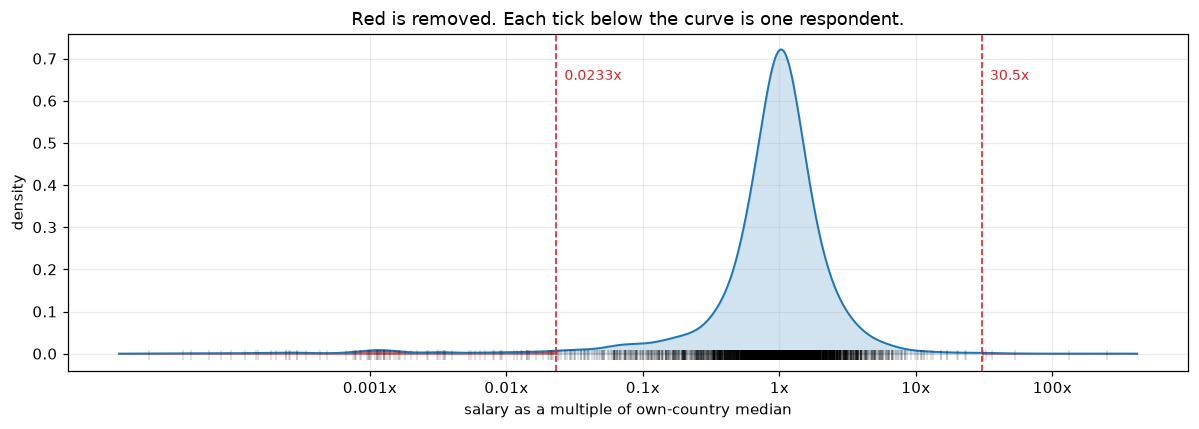

below 0.0233x : 95 rows
above 30.53x : 7 rows


In [3]:
ratio = country_median_ratio(with_salary)
log_ratio = np.log(ratio.to_numpy())
low, high = derive_salary_bounds(ratio)

grid = np.linspace(log_ratio.min() - 0.5, log_ratio.max() + 0.5, 1500)
curve = gaussian_kde(log_ratio)(grid)   # only to draw the shape

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(grid, curve, lw=1.3, color=KEEP)
ax.fill_between(grid, curve, alpha=0.2, color=KEEP)
ax.fill_between(grid, curve, where=grid < np.log(low), color=DROP, alpha=0.6)
ax.fill_between(grid, curve, where=grid > np.log(high), color=DROP, alpha=0.6)
ax.plot(log_ratio, np.full(len(log_ratio), -0.004), "|", ms=6, alpha=0.15, color="black")

for e, t in [(low, f"{low:.4f}x"), (high, f"{high:.1f}x")]:
    ax.axvline(np.log(e), color=DROP, ls="--", lw=1.1)
    ax.text(np.log(e), curve.max() * 0.9, f"  {t}", color=DROP, fontsize=9)

ticks = [0.001, 0.01, 0.1, 1, 10, 100]
ax.set_xticks(np.log(ticks)); ax.set_xticklabels([f"{t:g}x" for t in ticks])
ax.set_xlabel("salary as a multiple of own-country median")
ax.set_ylabel("density")
ax.set_title("Red is removed. Each tick below the curve is one respondent.")
plt.tight_layout(); plt.show()

print(f"below {low:.4f}x : {int((ratio < low).sum())} rows")
print(f"above {high:.2f}x : {int((ratio > high).sum())} rows")

## Pay period clusters

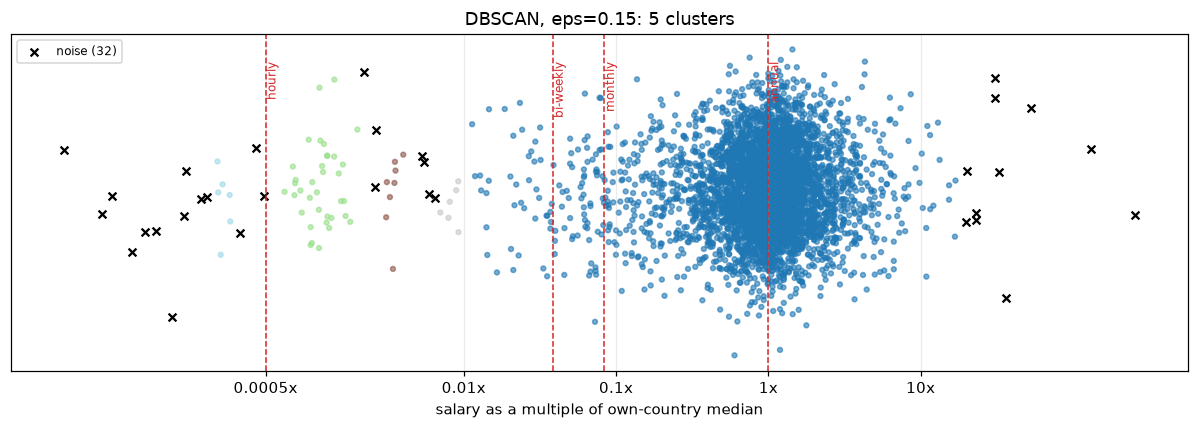

In [4]:
from sklearn.cluster import DBSCAN

labels = DBSCAN(eps=0.15, min_samples=5).fit_predict(log_ratio.reshape(-1, 1))
rng = np.random.default_rng(0)
jitter = rng.normal(0, 1, len(log_ratio))

fig, ax = plt.subplots(figsize=(11, 4))
noise = labels == -1
ax.scatter(log_ratio[~noise], jitter[~noise], c=labels[~noise], cmap="tab20",
           s=10, alpha=0.6)
ax.scatter(log_ratio[noise], jitter[noise], color="black", s=26, marker="x",
           label=f"noise ({int(noise.sum())})")

for frac, name in [(1.0, "annual"), (1/12, "monthly"), (1/26, "bi-weekly"), (1/2000, "hourly")]:
    ax.axvline(np.log(frac), color=DROP, ls="--", lw=1)
    ax.text(np.log(frac), ax.get_ylim()[1] * 0.82, f" {name}", color=DROP, fontsize=8,
            rotation=90, va="top")

ticks = [0.0005, 0.01, 0.1, 1, 10]
ax.set_xticks(np.log(ticks)); ax.set_xticklabels([f"{t:g}x" for t in ticks])
ax.set_xlabel("salary as a multiple of own-country median")
ax.set_yticks([])
ax.set_title(f"DBSCAN, eps=0.15: {len(set(labels)) - (1 if -1 in labels else 0)} clusters")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

## 3. Blank answers mean something

Three columns go blank together for the 527 people with no employer, so there was no
company size to report. Skipping a question also predicts pay.

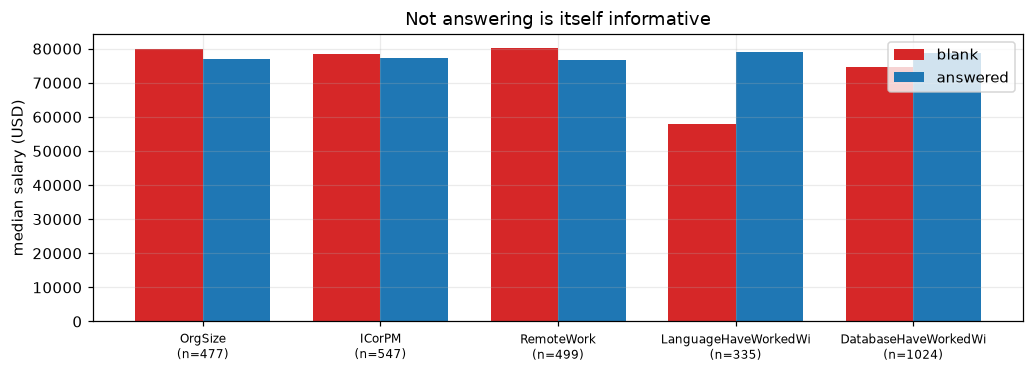

rows blank in OrgSize, ICorPM and RemoteWork all at once: 527


In [5]:
cols = ["OrgSize", "ICorPM", "RemoteWork", "LanguageHaveWorkedWith", "DatabaseHaveWorkedWith"]

rows = []
for col in cols:
    m = with_salary[col].isna()
    rows.append({"column": col, "blank": int(m.sum()),
                 "median if blank": with_salary[m][TARGET].median(),
                 "median if answered": with_salary[~m][TARGET].median()})
t = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9.5, 3.5))
x = np.arange(len(t)); w = 0.38
ax.bar(x - w/2, t["median if blank"], w, label="blank", color=DROP)
ax.bar(x + w/2, t["median if answered"], w, label="answered", color=KEEP)
ax.set_xticks(x)
ax.set_xticklabels([f"{c[:20]}\n(n={n})" for c, n in zip(t.column, t.blank)], fontsize=8)
ax.set_ylabel("median salary (USD)"); ax.legend()
ax.set_title("Not answering is itself informative")
plt.tight_layout(); plt.show()

print(f"rows blank in OrgSize, ICorPM and RemoteWork all at once: "
      f"{int(RAW[['OrgSize','ICorPM','RemoteWork']].isna().all(axis=1).sum())}")

Skipping the languages question comes with a $21,000 lower median. So blanks become a
category called "Unknown" rather than being filled in with a guess or dropped.

## 4. Impossible experience

`WorkExp` is paid employment, so it has to fit inside a working life.

`YearsCode` is checked against age itself to make sure its not greater.

The whole row is dropped rather than just the bad number. Five of these seven rows also
report a salary beyond 3x or below a third of their country's median, so the impossibility
is a signal about the respondent rather than about one cell.

## 5. The other column decisions

None of these remove rows, and none needed a chart.

| Column | Decision | Why |
|---|---|---|
| `Currency` | dropped, replaced by a foreign-currency flag | Matches the country's usual currency for 94% of rows, so it repeats `Country` |
| `ResponseId` | dropped | A row number |
| missing values | read as blanks, not the text `"NA"` | Otherwise the whole column silently becomes text |
| `EdLevel`, `Age`, `OrgSize` | kept as categories, not ranks | Pay is not perfectly ordered along them, and categories tested better |
| `EdLevel` write-ins | merged into secondary school | They sit at 0.78x of country median against secondary school's 0.80x |
| `OrgSize` non-headcounts | set to blank | It is a headcount scale, and "Just me" is already recorded under `Employment` |
| skills columns | split into flags for the top 20 languages and 12 databases | One cell holds several answers, so raw values are nearly unique |

## 6. The result

189 rows removed, 3.8%. The distribution keeps its shape.

The right panel is the check that matters: because implausibility is judged against local
pay, no country loses a large share of its respondents. A flat $5,000 floor would have taken
two thirds of Nigeria.

Modelling is in `model_results.ipynb`.